In [4]:
import os, sys, glob
# from abc import ABCMeta, abstractmethod, abstractproperty
import abc
from enum import Enum
from astropy.coordinates import Angle, SkyCoord
import astropy.units as u
import json

import space_phot
from astropy.io import fits
from jwst.associations import asn_from_list
from jwst.associations.lib.rules_level3_base import DMS_Level3_Base
from jwst.pipeline import Image3Pipeline
from jwst.skymatch import SkyMatchStep
from jwst.datamodels import ModelLibrary

# Hack - I moved this into a local notebooks dir...
# sys.path.append("/Users/mgriggio/diffpype/src/jwst_diff")
sys.path.append("/Users/dcoulter/Code/diffpype/src/jwst_diff")
from image1overf import sub1fimaging

# sys.path.append("/Users/mgriggio/diffpype/src/workflow_manager")
sys.path.append("/Users/dcoulter/Code/diffpype/src/workflow_manager")
from data_repository import RepositoryFactory 
from data_utils import DataUtils
from visualization import Visualizer


from shapely.geometry import Point
from shapely.geometry.polygon import Polygon

from mocpy import MOC
from mocpy import WCS as mocWCS
from astropy.wcs import WCS
import matplotlib.pyplot as plt
from astropy.time import Time
import numpy as np

import pandas as pd
import mysql.connector

import mysql.connector
from mysql.connector import Error
from mysql.connector.pooling import MySQLConnectionPool
from pprint import pprint
import math

import pdb

import healpy as hp



# Simulate data access layer

In [5]:
jwst_sw_linear_size = 1.054 # arcmin on a side
jwst_sw_module_area_sq_deg = (2040*0.031/3600)**2
print("\nArea per JWST SW module: %s deg^2" % jwst_sw_module_area_sq_deg)

JWST_MODULE_NSIDE = 2097152
power_of_two = int(np.log10(JWST_MODULE_NSIDE)/np.log10(2))
print("Max Depth: %s" % power_of_two)
jwst_hp_area_sq_deg = hp.nside2pixarea(nside=JWST_MODULE_NSIDE, degrees=True)
print("Area per JWST_MODULE_NSIDE %s pixel: %s deg^2" % (JWST_MODULE_NSIDE, jwst_hp_area_sq_deg))

hp_per_jwst = jwst_sw_module_area_sq_deg/jwst_hp_area_sq_deg
print("JWST_MODULE_NSIDE pixels per native JWST SW module: %s" % hp_per_jwst)


GLOBAL_CONFIG = {
    "mysql_config": {
        'host': '127.0.0.1',
        'port':'3307',
        'database': 'diffpype3',
        'user': 'dev',
        'password': 'devpass'
    },
    "filesystem_config": {
        "mast_proxy":"/astro/armin/data/mgriggio/nexus/MAST_2025-07-25T20_02_07.026Z/JWST/mastDownload/JWST/cal",
        "base_dir":"/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline"
    },
    "moc_settings":{
        "moc_max_depth":power_of_two
    }

}

repo_type = "mysql"
data_repo = RepositoryFactory.get_repository(repo_type, GLOBAL_CONFIG)

# Retrieve images hits the db to get images. This will come from a MAST query in the future
# image_df = data_repo.retrieve_images()
# print(len(image_df))


project_name = 'NEXUS'
project_df = data_repo.save_project(project_name)
pprint(project_df)
project_id = project_df.loc[0, 'id']

data_repo.set_project_context(project_df)


Area per JWST SW module: 0.0003085877777777778 deg^2
Max Depth: 21
Area per JWST_MODULE_NSIDE 2097152 pixel: 7.816531185164738e-10 deg^2
JWST_MODULE_NSIDE pixels per native JWST SW module: 394788.6478895614
DataUtils instance initialized with `moc_max_depth`: 21
Connection pool 'mypool' initialized with size 5.
Returning Project: NEXUS
Record already exists! Returning existing...
   id   name
0   1  NEXUS
Project directories created.


In [3]:
# Execute MAST query (proxy) to get raw image files into the raw image dir
raw_images = data_repo.get_images_from_MAST()
# data_repo.save_images(raw_images)

Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014016_06101_00001_nrcalong_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105003002_03201_00002_nrcb1_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014004_06101_00002_nrcb3_cal.fits' already exists, skipping.
Created symlink: '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105004005_02101_00002_nrcb2_cal.fits' -> '/astro/armin/data/mgriggio/nexus/MAST_2025-07-25T20_02_07.026Z/JWST/mastDownload/JWST/cal/jw05105004005_02101_00002_nrcb2_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105004002_02101_00002_nrcb2_cal.fits' -> '/astro/armin/data/mgriggio/nexus/MAST_2025-07-25T20_02_07.026Z/JWST/mastDownload/JWST/cal/jw05105004002_02101_0

Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014007_02101_00002_nrcb2_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014022_08101_00002_nrca2_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105001003_05101_00002_nrcb1_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014021_05101_00002_nrca1_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014016_08101_00002_nrcb4_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014021_08101_00002_nrcb2_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_

Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014017_02101_00002_nrca1_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105001004_08101_00001_nrca2_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105015001_03101_00001_nrcb1_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014010_03101_00001_nrcblong_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014008_03101_00001_nrca2_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014002_09101_00001_nrcblong_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/wo

Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105001001_02101_00002_nrca2_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014026_05101_00001_nrcb1_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105001006_02101_00002_nrcb2_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105002002_02101_00002_nrcalong_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014008_02101_00001_nrca1_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105001008_06101_00001_nrcblong_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/wo

Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014008_08101_00002_nrcb1_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014004_09101_00002_nrcb3_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014016_02101_00001_nrcb1_cal.fits' already exists, skipping.
Created symlink: '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105004002_02101_00002_nrcb3_cal.fits' -> '/astro/armin/data/mgriggio/nexus/MAST_2025-07-25T20_02_07.026Z/JWST/mastDownload/JWST/cal/jw05105004002_02101_00002_nrcb3_cal.fits'
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014008_03101_00001_nrcalong_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014

...

Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014016_05101_00001_nrca4_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014022_02101_00001_nrca1_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105001006_02101_00001_nrca1_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014017_08101_00002_nrcb2_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105015001_08101_00002_nrcb1_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014024_02101_00001_nrca2_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_

Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014023_02101_00001_nrca1_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014018_02101_00002_nrcb4_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014013_05101_00002_nrcb2_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014025_08101_00001_nrcblong_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014022_06101_00001_nrca1_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014008_06101_00001_nrcb4_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/worki

Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014014_06101_00001_nrcblong_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105001006_05101_00001_nrca3_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014009_05101_00001_nrca1_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014003_03101_00002_nrcb4_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014007_08101_00001_nrca4_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014022_02101_00002_nrca3_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/worki

Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014001_06101_00001_nrca3_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014015_06101_00001_nrca1_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014005_06101_00001_nrca4_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014008_02101_00002_nrcb1_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105001010_05101_00001_nrcb2_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014025_02101_00002_nrca3_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_

Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014019_05101_00002_nrca1_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014007_02101_00001_nrca3_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014022_05101_00002_nrca1_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014014_08101_00002_nrcb3_cal.fits' already exists, skipping.
Performing UPSERT of raw images to the database...
Returning image table from database.


In [4]:
# Filter which of these files we wish to enter the pipeline -- e.g., remove everything with exp_time < 100 seconds, etc.
IMAGE_WHERE = [
    'exp_time > 10.0',
    'id > 0'
]

# Save images to Lvl2Cal table
lvl2_df = data_repo.import_images_to_lvl2cals(IMAGE_WHERE)

# Or, if they already exist:
# lvl2_df = data_repo.retrieve_lvl2_cals()

pprint(len(lvl2_df))



Performing UPSERT of lvl2 cals to the database...
Returning Image JOIN with Lvl2s table from database.
2992


# RELOAD

In [8]:
from concurrent.futures import ProcessPoolExecutor, as_completed
#Helpful re-load 
import importlib
import visualization
import data_repository
import data_utils

importlib.reload(visualization)
importlib.reload(data_repository)
importlib.reload(data_utils)

# viz = visualization.Visualizer("/Users/dcoulter/Code/notebooks/diffpype/images/")
data_repo = RepositoryFactory.get_repository(repo_type, GLOBAL_CONFIG)
project_name = 'NEXUS'
project_df = data_repo.save_project(project_name)
pprint(project_df)
project_id = project_df.loc[0, 'id']
data_repo.set_project_context(project_df)

# lvl2_df = data_repo.retrieve_lvl2_cals()
# project_df = data_repo.retrieve_project(project_name)
# project_id = project_df.loc[0, 'id']
# tiles_df = data_repo.retrieve_tiles(project_name)
# tile_image_dict = data_repo.retrieve_tile_image(project_name, tiles_df, lvl2_df)
# 
# viz = visualization.Visualizer("/Users/mgriggio/Desktop")

Connection pool 'mypool' initialized with size 5.
Returning Project: NEXUS
Record already exists! Returning existing...
   id   name
0   1  NEXUS
Project directories created.


In [9]:
# unioned_image_moc = data_utils.DataUtils.Get_Unioned_MOC(lvl2_df.moc)
# tile_dataframe = data_utils.DataUtils.GenerateSkyTiles(project_id=project_id,
#                                             tile_side_length_arc_min=2.5, 
#                                             overlap_in_arc_min=0.25, 
#                                             moc_to_tile=unioned_image_moc)
tile_dataframe = data_repo.retrieve_tiles(project_name)

unioned_tile_moc = data_utils.DataUtils.Get_Unioned_MOC(tile_dataframe.moc)

covered_area = unioned_tile_moc.sky_fraction*41253
fov_proxy = 1.75*np.sqrt(covered_area) # add a fudge factor since areas aren't circles...
barycenter = unioned_tile_moc.barycenter()

viz = visualization.Visualizer("/Users/mgriggio/Desktop")
viz.plot_footprint_and_epochs(moc_list=lvl2_df.moc, 
                              epoch_list=lvl2_df.mjd_avg, 
                              footprint_title="Total Footprint", 
                              hist_title="Total Epochs", 
                              central_coord=barycenter, 
                              fov_degrees=fov_proxy, 
                              tile_df=tile_dataframe)

Returning Project: NEXUS
Tiles for `NEXUS` do not exist
Returning tiles for Project: NEXUS


KeyError: 0

In [ ]:
# tiles_df = data_repo.save_tiles(tile_dataframe, project_name, clobber=True) 
# tiles_df = data_repo.save_tiles(tile_dataframe, project_name)
# pprint(len(tiles_df))

tiles_df = data_repo.retrieve_tiles(project_name)
print(tiles_df['name'].to_string(index=False))

In [32]:
# No safety on this -- it will just duplicate if saved again... can fix with an UPSERT specifying that the combination of lvl2 id and tile id is UNIQUE
tile_image_dict = data_repo.save_tile_image_association(project_name, tiles_df, lvl2_df)

Returning Project: NEXUS
Returning Project: NEXUS
Returning tile-lvl2 relation for Project: NEXUS


In [33]:
tile_image_dict = data_repo.retrieve_tile_image(project_name, tiles_df, lvl2_df)

tile_ids = tile_image_dict.keys()
tile_names = [tiles_df[tiles_df["id"]==_id].name.iloc[0] for _id in tile_ids]


print("Tile ID, Tile Name, Filter Tuples")
for _id, _name in zip(tile_ids, tile_names):
    band_id_per_tile = tile_image_dict[_id].band_id.to_list()
    _tmp_b = []
    for b in band_id_per_tile:
        _tmp_b.append(b)
    uniq_b = set(_tmp_b)
    b_names = [data_repo.reverse_bands[b] for b in uniq_b]
    print(_id, _name, [(b_id, b_name) for (b_id, b_name) in zip(uniq_b, b_names)])
    
        
# pprint(type(tile_image_dict[128]))


Returning Project: NEXUS
Returning tile-lvl2 relation for Project: NEXUS
Tile ID, Tile Name, Filter Tuples
119 Tile_1 [(9, 'F090W')]
120 Tile_2 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (6, 'F356W'), (9, 'F090W'), (16, 'F444W')]
121 Tile_3 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (6, 'F356W'), (9, 'F090W'), (16, 'F444W')]
122 Tile_4 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (6, 'F356W'), (9, 'F090W'), (16, 'F444W')]
123 Tile_5 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (6, 'F356W'), (9, 'F090W'), (16, 'F444W')]
124 Tile_6 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (6, 'F356W'), (9, 'F090W'), (16, 'F444W')]
125 Tile_7 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (6, 'F356W'), (9, 'F090W'), (16, 'F444W')]
126 Tile_8 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (6, 'F356W'), (9, 'F090W'), (16, 'F444W')]
127 Tile_9 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (6, 'F356W'), (9, 'F090W'), (16, 'F444W')]
128 Tile_10 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (6, 'F356W'), (9, 'F090W'), (16, 'F4

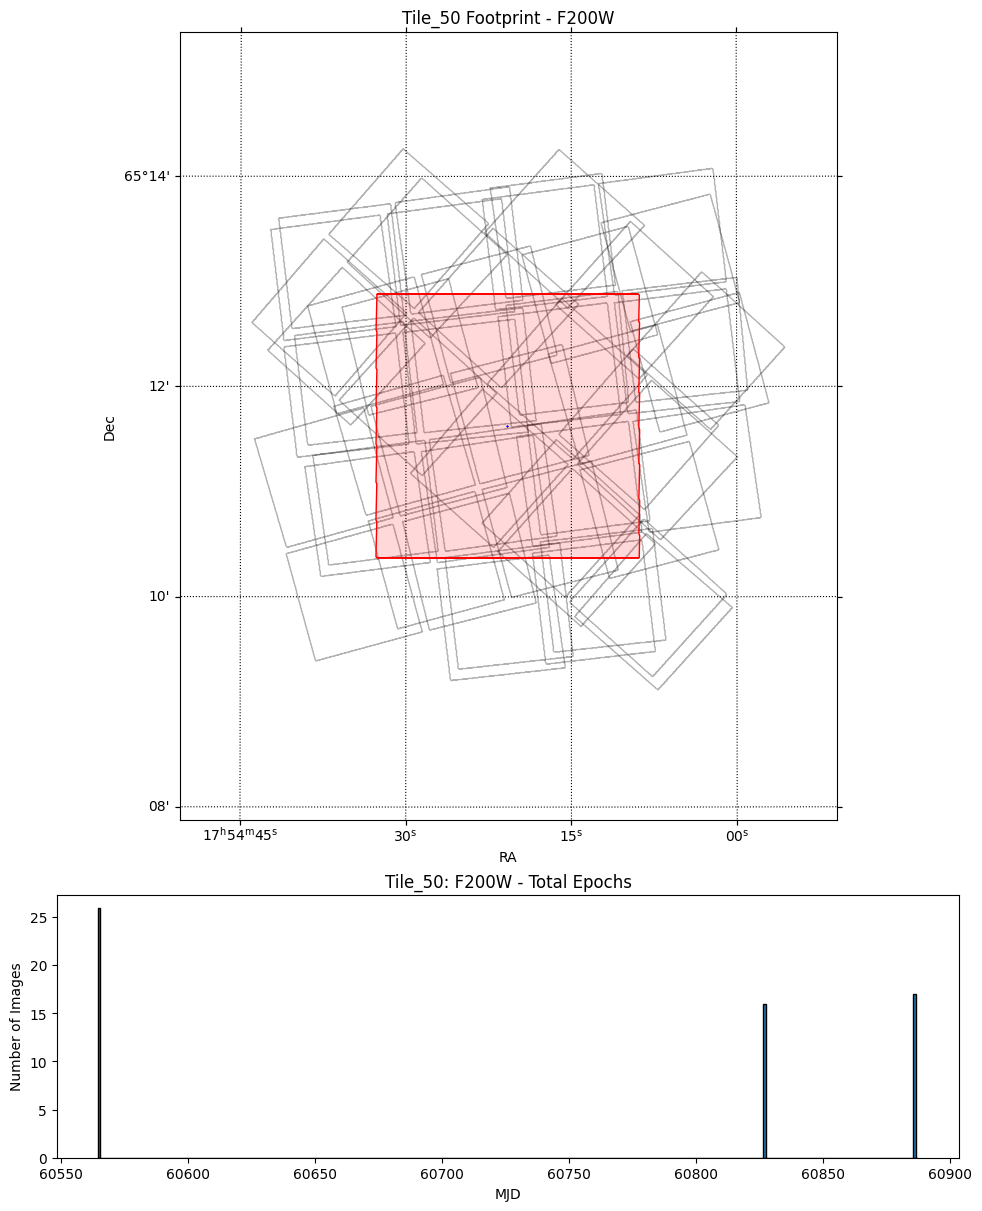

In [34]:
tile_id = 168 # Tile 1
filter_tups = [(3, 'F200W')]
# filter_tups = [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (6, 'F356W'), (8, 'F444W')]
# filter_tups = [(3, 'F200W'), (8, 'F444W')]
# filter_tups = [(8, 'F444W')]
# filter_tups = [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (6, 'F356W'), (9, 'F090W'), (12, 'F210M'), (16, 'F444W'), (17, 'F360M')]
viz.plot_tile_contents(image_dataframe=tile_image_dict[tile_id], tile_dataframe=tiles_df, filter_tuples=filter_tups, tile_id=tile_id, fov_scale=2.5)


In [36]:
do_save = True
distance_thresh = 50

# For tile, for filter -> grab epochs from the resulting image list
for tile_id, images_in_tile in tile_image_dict.items():
    
    for _band_id in images_in_tile["band_id"].unique():        
        
        in_band_images = images_in_tile[images_in_tile["band_id"] == _band_id]
        in_band_mjds = list(in_band_images.mjd_avg)
        epochs = DataUtils.CreateEpochsFromMJDs(in_band_mjds, peak_distance_thresh=distance_thresh)
        
        if do_save:
            data_repo.save_tile_epochs(start_mjds=epochs[:,0], end_mjds=epochs[:,1], tile_id=tile_id, band_id=_band_id, project_id=project_id)

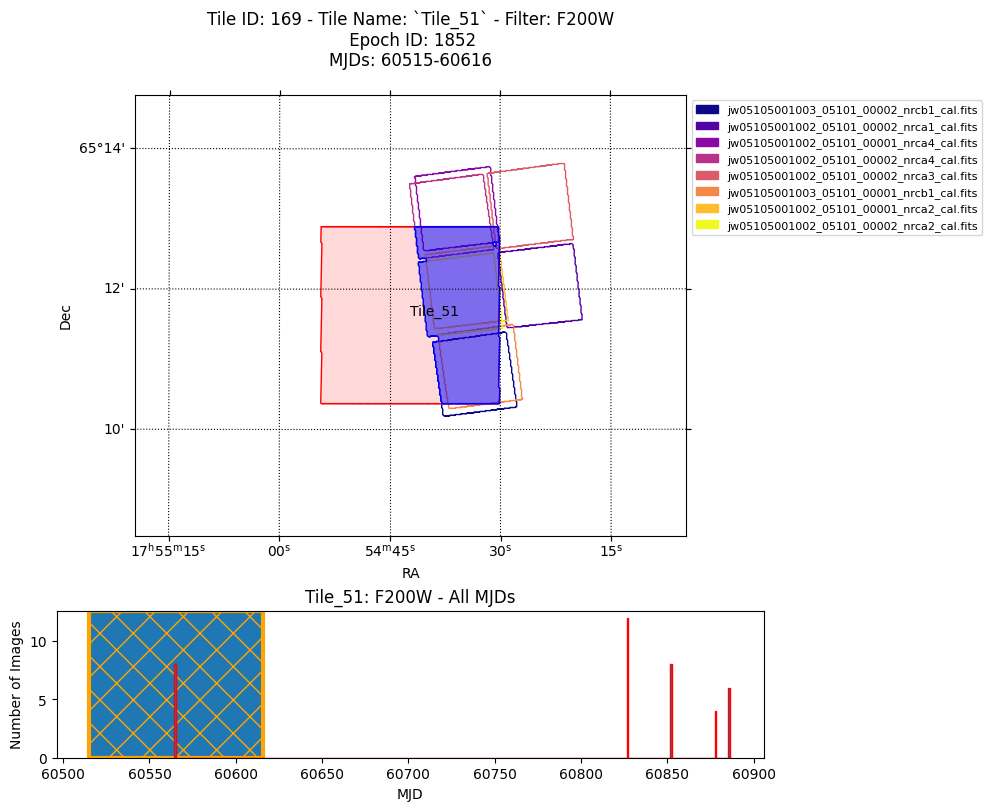

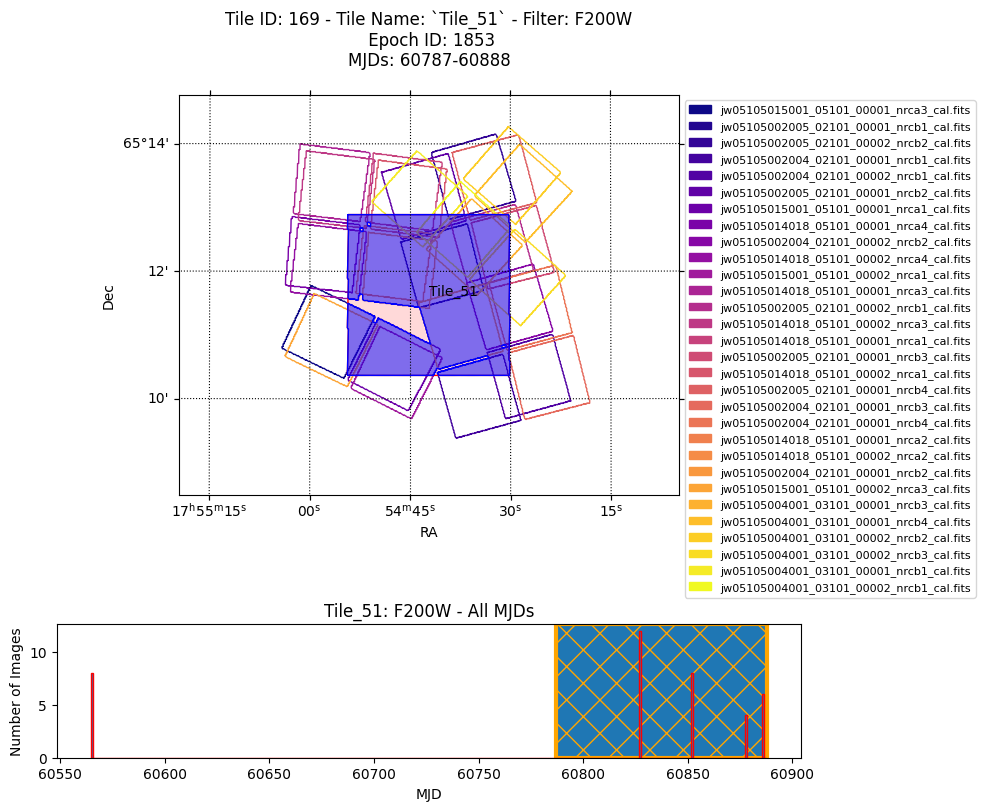

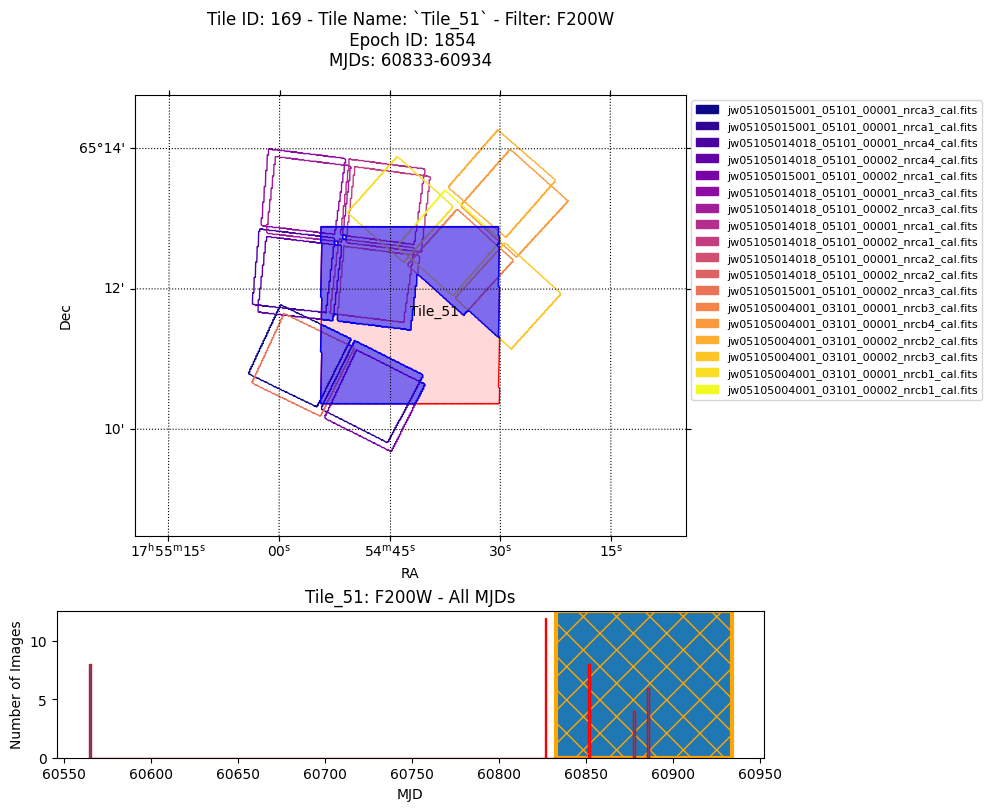

In [85]:
# Plot any combination of tile and band
_tile_id = 169
_tile_filter_tuple = (3, 'F200W')
# _tile_id = 17
# _tile_filter_tuple = (1, 'F115W')
# _tile_filter_tuple = (12, 'F210M')


# _tile_filter_tuple = (8, 'F444W')


_tile_df = tiles_df[tiles_df["id"] == _tile_id]
_tile_obj = _tile_df.iloc[0]
_tile_epochs = data_repo.retrieve_tile_epochs(tile_id=_tile_id, band_id=_tile_filter_tuple[0], project_id=project_id)
_tile_img_df = tile_image_dict[_tile_id]

for _tp_index, _tp in _tile_epochs.iterrows(): 
    _ep_start = _tp["start_mjd"]
    _ep_stop = _tp["end_mjd"]
    
    _in_epoch_imgs = _tile_img_df[(_tile_img_df.mjd_avg >= _ep_start) & (_tile_img_df.mjd_avg <= _ep_stop) & (_tile_img_df.band_id == _tile_filter_tuple[0])]
    
    viz.plot_epochs(all_image_dataframe=_tile_img_df, epoch_image_dataframe=_in_epoch_imgs, tile_dataframe=tiles_df, filter_tuple=_tile_filter_tuple, tile_id=_tile_id, fov_scale=2.5, epoch_record=_tp)
    
    # break

In [43]:
# Save tile-epoch-lvl2 => mosaic
# We have to create a lvl3 record, and then use the ID to create the lvl2->lvl3 lookup table to create the mosaic
#   Mosaic = Tile ID, Band ID, Epoch ID  

# Iterate over all tiles
#   Over all unique bands
#       Over all enclosed images by band
#       Group by epoch
#           Save unique combo of tile_id, band_id, image_id, epoch_id
for tile_id, lvl2_in_tile in tile_image_dict.items():
    
    for band_id in lvl2_in_tile["band_id"].unique():
        in_band_tile_epochs = data_repo.retrieve_tile_epochs(tile_id=tile_id, band_id=band_id, project_id=project_id)
        
        for index, epoch in in_band_tile_epochs.iterrows():

            # Create lvl2-epoch records
            start_mjd = epoch["start_mjd"]
            end_mjd = epoch["end_mjd"]
            epoch_id = epoch["id"]
            in_epoch_lvl2 = lvl2_in_tile[(lvl2_in_tile.mjd_avg >= start_mjd) & (lvl2_in_tile.mjd_avg <= end_mjd) & (lvl2_in_tile.band_id == band_id)]
            
            # Save the association
            lvl2_epoch_assc = data_repo.save_epoch_lvl2cal_association(epoch_id, in_epoch_lvl2)
            
            # Create lvl3mosaic obj
            lvl3mosaic = data_repo.save_lvl3mosaic(project_id, tile_id, band_id, epoch_id, in_epoch_lvl2)

Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from da

Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the data

Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from da

Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from da

Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the data

...

Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the data

Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from da

Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the data

Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the data

Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the data

# Start with the state that the database is populated

In [6]:
# project_name = 'NEXUS'
project_df = data_repo.retrieve_project(project_name)
image_df = data_repo.retrieve_images()
lvl2_df = data_repo.retrieve_lvl2_cals()
tiles_df = data_repo.retrieve_tiles(project_name)
tile_image_dict = data_repo.retrieve_tile_image(project_name, tiles_df, lvl2_df)
lvl3mosaic_df = data_repo.retrieve_lvl3mosaic_by_project(project_name)


Returning Project: NEXUS
Returning image table from database.
Returning Image JOIN with Lvl2s table from database.
Returning Project: NEXUS
Tiles for `NEXUS` do not exist
Returning tiles for Project: NEXUS
Returning Project: NEXUS
Error executing SQL query: 1064 (42000): You have an error in your SQL syntax; check the manual that corresponds to your MySQL server version for the right syntax to use near ') AND project_id = 1' at line 5
Query: 
            SELECT 
                lvl2.id,lvl2.tile_id,lvl2.lvl2cal_id 
            FROM Tile_Lvl2Cal lvl2
            JOIN Tile t on t.id = lvl2.tile_id
            WHERE Tile_id IN () AND project_id = 1
        
Values: None
Returning tile-lvl2 relation for Project: NEXUS
Returning Project: NEXUS
Lvl3Mosaic does not exist for Project ID=`1`. Returning... 


In [45]:
# # Reset status
# lvl2_df['current_file_ext'] = '.fits'
# lvl2_df['lvl2cal_status_id'] = 1
# lvl2_df = data_repo.save_lvl2_cals(lvl2_df)

Performing UPSERT of lvl2 cals to the database...
Returning Image JOIN with Lvl2s table from database.


In [83]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp
sys.path.append("/Users/mgriggio/diffpype/src/steps")
import Executors
import OneOverF
import BkgSub
import Mosaic
import importlib
importlib.reload(OneOverF)
importlib.reload(Executors)
importlib.reload(BkgSub)
importlib.reload(Mosaic)

# print("Running 1overf")
# lvl2_cal_all = [tt[1] for tt in tile_image_dict.items()]
# lvl2_cal_all = [tt[1] for tt in tile_image_dict.items() if tt[0] == 168]

# for lvl2_cal in lvl2_cal_all:

#     lvl2_cal = lvl2_cal[lvl2_cal.band_id == 3]
#     # 1overf
#     inpdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'rawimage'])
#     outdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'working'])
#     logdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'logs/1overf'])

#     with Executors.Executor(kind='local').ex as executor:
#         futures = [executor.submit(OneOverF.oneoverf, lvl2_cal.loc[idx].base_filename.split('.')[0], '.fits', lvl2_cal.loc[idx].lvl2cal_id, inpdir, outdir, logdir) for idx in lvl2_cal.index]

#     err = False
#     for future in as_completed(futures):
#         res = future.result()
#         if(isinstance(res, tuple)):
#             if(res[0] != 0):
#                 print('An error occurred, check the logs for '+lvl2_df[lvl2_df.lvl2cal_id == res[1]].iloc[0].base_filename)
#                 err = True
#                 continue

#             idx = lvl2_df.index[lvl2_df.lvl2cal_id == res[1]][0]
#             lvl2_df.at[idx, 'lvl2cal_status_id'] = 2
#             lvl2_df.at[idx, 'current_file_ext'] = res[2]

#         else:
#             print('An error occurred: '+str(res))
#             err = True

# if(err == False):
#     lvl2_df = data_repo.save_lvl2_cals(lvl2_df)
# print("Done")


        
project_df = data_repo.retrieve_project(project_name)
image_df = data_repo.retrieve_images()
lvl2_df = data_repo.retrieve_lvl2_cals()
tiles_df = data_repo.retrieve_tiles(project_name)
tile_image_dict = data_repo.retrieve_tile_image(project_name, tiles_df, lvl2_df)
lvl3mosaic_df = data_repo.retrieve_lvl3mosaic_by_project(project_name)

lvl3_gb = lvl3mosaic_df.groupby(by=['tile_id','band_id']).epoch_id.nunique()>2
lvl3_todo = lvl3_gb[lvl3_gb].reset_index()

print("Running skymatch")
# lvl2_cal_all = [tt[1] for tt in tile_image_dict.items()]
# lvl2_cal_all = [tt[1] for tt in tile_image_dict.items() if tt[0] == 168]
# tile_ids, lvl2_cal_all = [(tt[0], tt[1]) for tt in tile_image_dict.items() if np.isin(tt[0],lvl3_todo.tile_id)]
tiles_lvl2 = [tt for tt in tile_image_dict.items() if np.isin(tt[0], lvl3_todo.tile_id)]

for t_id, lvl2_cal in tiles_lvl2:


    lvl2_cal = lvl2_cal[np.isin(lvl2_cal.band_id, lvl3_todo[lvl3_todo.tile_id == t_id].band_id)]
    
    # skymatch
    inpdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'rawimage'])
    outdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'working'])  
    logdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'logs/skymatch'])

    with Executors.Executor(kind='local').ex as executor:
        futures = [executor.submit(BkgSub.subtract_background, lvl2_cal.loc[idx].base_filename.split('.')[0], lvl2_cal.loc[idx].current_file_ext, lvl2_cal.loc[idx].lvl2cal_id, inpdir, outdir, logdir) for idx in lvl2_cal.index]

    err = False
    for future in as_completed(futures):
        res = future.result()
        if(isinstance(res, tuple)):
            if(res[0] != 0):
                print('An error occurred, check the logs for '+lvl2_df[lvl2_df.lvl2cal_id == res[1]].iloc[0].base_filename)
                err = True
                continue

            idx = lvl2_df.index[lvl2_df.lvl2cal_id == res[1]][0]
            lvl2_df.at[idx, 'lvl2cal_status_id'] = 3
            lvl2_df.at[idx, 'current_file_ext'] = res[2]

        else:
            print('An error occurred: '+str(res))
            err = True

if(err == False):
    lvl2_df = data_repo.save_lvl2_cals(lvl2_df)
print("Done")


# project_df = data_repo.retrieve_project(project_name)
# image_df = data_repo.retrieve_images()
# lvl2_df = data_repo.retrieve_lvl2_cals()
# tiles_df = data_repo.retrieve_tiles(project_name)
# tile_image_dict = data_repo.retrieve_tile_image(project_name, tiles_df, lvl2_df)
# lvl3mosaic_df = data_repo.retrieve_lvl3mosaic_by_project(project_name)


# print("Running mosaic")
# # mosaic        
# inpdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'working'])
# outdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'working'])  
# logdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'logs/mosaic'])

# lvl2_in = [] 
# mosaic_out = []
# tile_params = []

# for mosaic_id in lvl3mosaic_df.index:
#     mosaic = lvl3mosaic_df.loc[mosaic_id]
#     mosaic_out.append(mosaic.filename)
#     tile_id = mosaic.tile_id
#     epoch_id = mosaic.epoch_id
#     band_id = mosaic.band_id
#     pix_scale = mosaic.target_plate_scale / 1000
#     CRVAL1 = mosaic.ra
#     CRVAL2 = mosaic.decl
#     tile_shape = np.array((tiles_df[tiles_df.id == tile_id].iloc[0].delta_ra, tiles_df[tiles_df.id == tile_id].iloc[0].delta_decl)) * 3600 / pix_scale
#     CRPIX1, CRPIX2 = tile_shape / 2
#     rotation = 0

#     # CRPIX1, CRPIX2, CRVAL1, CRVAL2, pix_scale, rotation, tile_shape
#     tile_params.append((CRPIX1, CRPIX2, CRVAL1, CRVAL2, pix_scale, rotation, tile_shape))

#     lvl2_epoch_df = data_repo.retrieve_epoch_lvl2cal_association(epoch_id)
#     lvl2_tile = tile_image_dict[tile_id]
#     lvl2_tile_epoch = lvl2_tile.merge(lvl2_epoch_df, on='lvl2cal_id')
#     lvl2_todrz = lvl2_tile_epoch[lvl2_tile_epoch.band_id==band_id]
    
#     lvl2_in.append([lvl2_todrz.loc[idx].base_filename.replace('.fits',lvl2_todrz.loc[idx].current_file_ext) for idx in lvl2_todrz.index])


# with ProcessPoolExecutor(max_workers=16) as ex:
#     futures = [ex.submit(Mosaic.create_mosaic, lvl2_in[i], mosaic_out[i], inpdir, outdir, logdir, tile_params[i]) for i in range(len(mosaic_out))]


# for future in as_completed(futures):
#     print(future.result()+' returned')

# print("Done")

Returning Project: NEXUS
Returning image table from database.
Returning Image JOIN with Lvl2s table from database.
Returning Project: NEXUS
Returning tiles for Project: NEXUS
Returning Project: NEXUS
Returning tile-lvl2 relation for Project: NEXUS
Returning Project: NEXUS
Returning Lvl3Mosaic JOIN with Tile and Epoch from database for Project: `NEXUS`
Running skymatch


2025-07-30 13:58:51,773 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-07-30 13:58:51,774 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-07-30 13:58:51,774 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-07-30 13:58:51,774 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-07-30 13:58:51,774 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-07-30 13:58:51,774 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-07-30 13:58:51,774 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-07-30 13:58:51,774 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-07-30 13:58:51,774 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-07-30 13:58:51,774 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-07-30 13:58:51,774 - stpipe.Image3Pipeline.assign_mtw

2025-07-30 13:59:09,978 - CRDS - INFO -  Calibration SW Found: jwst 1.18.0 (/opt/miniconda3/envs/new_base/lib/python3.12/site-packages/jwst-1.18.0.dist-info)
2025-07-30 13:59:09,989 - CRDS - INFO -  Calibration SW Found: jwst 1.18.0 (/opt/miniconda3/envs/new_base/lib/python3.12/site-packages/jwst-1.18.0.dist-info)
2025-07-30 13:59:10,006 - CRDS - INFO -  Calibration SW Found: jwst 1.18.0 (/opt/miniconda3/envs/new_base/lib/python3.12/site-packages/jwst-1.18.0.dist-info)
2025-07-30 13:59:10,052 - CRDS - INFO -  Calibration SW Found: jwst 1.18.0 (/opt/miniconda3/envs/new_base/lib/python3.12/site-packages/jwst-1.18.0.dist-info)
2025-07-30 13:59:10,058 - CRDS - INFO -  Calibration SW Found: jwst 1.18.0 (/opt/miniconda3/envs/new_base/lib/python3.12/site-packages/jwst-1.18.0.dist-info)
2025-07-30 13:59:10,090 - CRDS - INFO -  Calibration SW Found: jwst 1.18.0 (/opt/miniconda3/envs/new_base/lib/python3.12/site-packages/jwst-1.18.0.dist-info)
2025-07-30 13:59:10,107 - CRDS - INFO -  Calibration

2025-07-30 13:59:10,385 - CRDS - ERROR -  Error determining best reference for 'pars-davesbbskymatchstep'  =   Unknown reference type 'pars-davesbbskymatchstep'
2025-07-30 13:59:10,386 - stpipe - INFO - PARS-TWEAKREGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-tweakregstep_0045.asdf
2025-07-30 13:59:10,387 - stpipe - INFO - PARS-RESAMPLESTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-resamplestep_0001.asdf
2025-07-30 13:59:10,389 - stpipe - INFO - PARS-TWEAKREGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-tweakregstep_0045.asdf
2025-07-30 13:59:10,392 - CRDS - ERROR -  Error determining best reference for 'pars-davesbbskymatchstep'  =   Unknown reference type 'pars-davesbbskymatchstep'
2025-07-30 13:59:10,392 - stpipe - INFO - PARS-SOURCECATALOGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-sourcecatalogstep_0001.a

2025-07-30 13:59:39,153 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-07-30 13:59:39,153 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-07-30 13:59:39,154 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-07-30 13:59:39,155 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-07-30 13:59:39,156 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-07-30 13:59:39,156 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-07-30 13:59:39,157 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-07-30 13:59:39,244 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-07-30 13:59:39,244 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-07-30 13:59:39,245 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
20

...

2025-07-30 14:26:34,026 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-07-30 14:26:34,026 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-07-30 14:26:34,027 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-07-30 14:26:34,027 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-07-30 14:26:34,027 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-07-30 14:26:34,027 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-07-30 14:26:34,028 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-07-30 14:26:34,029 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-07-30 14:26:34,029 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-07-30 14:26:34,029 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
20

2025-07-30 14:26:34,439 - CRDS - INFO -  Calibration SW Found: jwst 1.18.0 (/opt/miniconda3/envs/new_base/lib/python3.12/site-packages/jwst-1.18.0.dist-info)
2025-07-30 14:26:34,459 - stpipe - INFO - PARS-TWEAKREGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-tweakregstep_0045.asdf
2025-07-30 14:26:34,465 - CRDS - ERROR -  Error determining best reference for 'pars-davesbbskymatchstep'  =   Unknown reference type 'pars-davesbbskymatchstep'
2025-07-30 14:26:34,467 - stpipe - INFO - PARS-RESAMPLESTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-resamplestep_0001.asdf
2025-07-30 14:26:34,472 - stpipe - INFO - PARS-SOURCECATALOGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-sourcecatalogstep_0001.asdf
2025-07-30 14:26:34,474 - CRDS - INFO -  Calibration SW Found: jwst 1.18.0 (/opt/miniconda3/envs/new_base/lib/python3.12/site-packages/jwst-1.18.0.dist-info)
2025-07-3

2025-07-30 14:26:35,238 - stpipe - INFO - PARS-TWEAKREGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-tweakregstep_0045.asdf
2025-07-30 14:26:35,243 - CRDS - ERROR -  Error determining best reference for 'pars-davesbbskymatchstep'  =   Unknown reference type 'pars-davesbbskymatchstep'
2025-07-30 14:26:35,245 - stpipe - INFO - PARS-RESAMPLESTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-resamplestep_0001.asdf
2025-07-30 14:26:35,249 - stpipe - INFO - PARS-SOURCECATALOGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-sourcecatalogstep_0001.asdf
2025-07-30 14:26:35,264 - stpipe - INFO - PARS-TWEAKREGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-tweakregstep_0036.asdf
2025-07-30 14:26:35,269 - CRDS - ERROR -  Error determining best reference for 'pars-davesbbskymatchstep'  =   Unknown reference type 'pars-davesbbskymatchst

2025-07-30 14:27:17,662 - CRDS - ERROR -  Error determining best reference for 'pars-davesbbskymatchstep'  =   Unknown reference type 'pars-davesbbskymatchstep'
2025-07-30 14:27:17,668 - CRDS - ERROR -  Error determining best reference for 'pars-davesbbskymatchstep'  =   Unknown reference type 'pars-davesbbskymatchstep'
2025-07-30 14:27:17,674 - CRDS - ERROR -  Error determining best reference for 'pars-davesbbskymatchstep'  =   Unknown reference type 'pars-davesbbskymatchstep'
2025-07-30 14:27:17,939 - CRDS - ERROR -  Error determining best reference for 'pars-davesbbskymatchstep'  =   Unknown reference type 'pars-davesbbskymatchstep'
2025-07-30 14:27:17,943 - CRDS - ERROR -  Error determining best reference for 'pars-davesbbskymatchstep'  =   Unknown reference type 'pars-davesbbskymatchstep'
2025-07-30 14:27:17,950 - CRDS - ERROR -  Error determining best reference for 'pars-davesbbskymatchstep'  =   Unknown reference type 'pars-davesbbskymatchstep'
2025-07-30 14:27:17,962 - CRDS - E

Performing UPSERT of lvl2 cals to the database...
Returning Image JOIN with Lvl2s table from database.
Done


In [84]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp
sys.path.append("/Users/mgriggio/diffpype/src/steps")
import Executors
import OneOverF
import BkgSub
import Mosaic
import importlib
importlib.reload(OneOverF)
importlib.reload(Executors)
importlib.reload(BkgSub)
importlib.reload(Mosaic)

project_df = data_repo.retrieve_project(project_name)
image_df = data_repo.retrieve_images()
lvl2_df = data_repo.retrieve_lvl2_cals()
tiles_df = data_repo.retrieve_tiles(project_name)
tile_image_dict = data_repo.retrieve_tile_image(project_name, tiles_df, lvl2_df)
lvl3mosaic_df = data_repo.retrieve_lvl3mosaic_by_project(project_name)

lvl3_gb = lvl3mosaic_df.groupby(by=['tile_id','band_id']).epoch_id.nunique()>2
lvl3_todo = lvl3_gb[lvl3_gb].reset_index()

print("Running mosaic")
# mosaic        
inpdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'working'])
outdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'working'])  
logdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'logs/mosaic'])

lvl2_in = [] 
mosaic_out = []
tile_params = []

for mosaic_id in lvl3mosaic_df.index:
    
    mosaic = lvl3mosaic_df.loc[mosaic_id]
    tile_id = mosaic.tile_id
    epoch_id = mosaic.epoch_id
    band_id = mosaic.band_id
    if(not np.isin(band_id, lvl3_todo[lvl3_todo.tile_id == tile_id].band_id) ):
        continue
    
    mosaic_out.append(mosaic.filename)
    
    pix_scale = mosaic.target_plate_scale / 1000
    CRVAL1 = mosaic.ra
    CRVAL2 = mosaic.decl
    tile_shape = np.array((tiles_df[tiles_df.id == tile_id].iloc[0].delta_ra, tiles_df[tiles_df.id == tile_id].iloc[0].delta_decl)) * 3600 / pix_scale
    CRPIX1, CRPIX2 = tile_shape / 2
    rotation = 0

    # CRPIX1, CRPIX2, CRVAL1, CRVAL2, pix_scale, rotation, tile_shape
    tile_params.append((CRPIX1, CRPIX2, CRVAL1, CRVAL2, pix_scale, rotation, tile_shape))

    lvl2_epoch_df = data_repo.retrieve_epoch_lvl2cal_association(epoch_id)
    lvl2_tile = tile_image_dict[tile_id]
    lvl2_tile_epoch = lvl2_tile.merge(lvl2_epoch_df, on='lvl2cal_id')
    lvl2_todrz = lvl2_tile_epoch[lvl2_tile_epoch.band_id==band_id]

    lvl2_in.append([lvl2_todrz.loc[idx].base_filename.replace('.fits',lvl2_todrz.loc[idx].current_file_ext) for idx in lvl2_todrz.index])


with ProcessPoolExecutor(max_workers=16) as ex:
    futures = [ex.submit(Mosaic.create_mosaic, lvl2_in[i], mosaic_out[i], inpdir, outdir, logdir, tile_params[i]) for i in range(len(mosaic_out))]


for future in as_completed(futures):
    print(str(future.result())+' returned')

print("Done")

Returning Project: NEXUS
Returning image table from database.
Returning Image JOIN with Lvl2s table from database.
Returning Project: NEXUS
Returning tiles for Project: NEXUS
Returning Project: NEXUS
Returning tile-lvl2 relation for Project: NEXUS
Returning Project: NEXUS
Returning Lvl3Mosaic JOIN with Tile and Epoch from database for Project: `NEXUS`
Running mosaic


2025-07-30 14:28:12,795 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-07-30 14:28:12,795 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-07-30 14:28:12,796 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-07-30 14:28:12,796 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-07-30 14:28:12,797 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-07-30 14:28:12,797 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-07-30 14:28:12,797 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-07-30 14:28:12,802 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-07-30 14:28:12,802 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-07-30 14:28:12,803 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
20

2025-07-30 14:28:13,457 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-07-30 14:28:13,458 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-07-30 14:28:13,459 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-07-30 14:28:13,459 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-07-30 14:28:13,459 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-07-30 14:28:13,460 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-07-30 14:28:13,460 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-07-30 14:28:13,761 - CRDS - INFO -  Calibration SW Found: jwst 1.18.0 (/opt/miniconda3/envs/new_base/lib/python3.12/site-packages/jwst-1.18.0.dist-info)
2025-07-30 14:28:14,052 - stpipe - INFO - PARS-TWEAKREGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_ni

2025-07-30 14:28:26,971 - stpipe - INFO - PARS-TWEAKREGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-tweakregstep_0045.asdf
2025-07-30 14:28:26,978 - stpipe - INFO - PARS-RESAMPLESTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-resamplestep_0001.asdf
2025-07-30 14:28:26,983 - stpipe - INFO - PARS-SOURCECATALOGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-sourcecatalogstep_0001.asdf
2025-07-30 14:28:27,670 - CRDS - INFO -  Calibration SW Found: jwst 1.18.0 (/opt/miniconda3/envs/new_base/lib/python3.12/site-packages/jwst-1.18.0.dist-info)
2025-07-30 14:28:27,944 - stpipe - INFO - PARS-TWEAKREGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-tweakregstep_0045.asdf
2025-07-30 14:28:27,952 - stpipe - INFO - PARS-RESAMPLESTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-resamplestep_00

! WARNING: Clipped data falls within 1 histogram bin
! WARNING: Clipped data falls within 1 histogram bin
! WARNING: Clipped data falls within 1 histogram bin
NEXUS_NIRCAM_Tile_60_F200W_60836.0_60937.0_30.0.lvl3.fits returned
NEXUS_NIRCAM_Tile_28_F444W_60836.0_60937.0_60.0.lvl3.fits returned
NEXUS_NIRCAM_Tile_62_F200W_60787.0_60888.0_30.0.lvl3.fits returned
NEXUS_NIRCAM_Tile_47_F444W_60777.0_60878.0_60.0.lvl3.fits returned
NEXUS_NIRCAM_Tile_40_F200W_60836.0_60937.0_30.0.lvl3.fits returned
NEXUS_NIRCAM_Tile_37_F444W_60777.0_60878.0_60.0.lvl3.fits returned
NEXUS_NIRCAM_Tile_50_F200W_60836.0_60937.0_30.0.lvl3.fits returned
NEXUS_NIRCAM_Tile_41_F200W_60515.0_60616.0_30.0.lvl3.fits returned
NEXUS_NIRCAM_Tile_50_F444W_60836.0_60937.0_60.0.lvl3.fits returned
NEXUS_NIRCAM_Tile_38_F444W_60777.0_60878.0_60.0.lvl3.fits returned
NEXUS_NIRCAM_Tile_40_F200W_60777.0_60878.0_30.0.lvl3.fits returned
NEXUS_NIRCAM_Tile_28_F444W_60794.0_60895.0_60.0.lvl3.fits returned
NEXUS_NIRCAM_Tile_40_F444W_60515.0_60

In [2]:
radec = [(268.5578907,65.2691669),
(268.26670934,65.15703811),
(268.46326409,65.26776912),
(268.41857812,65.19983524),
(268.41504216,65.19169356),
(268.29707577,65.1454623),
(268.49352718,65.20623894),
(268.457624,65.25954131),
(268.34249025,65.13601799),
(268.28873529,65.19379818),
(268.54181577,65.20325092),
(268.59558372,65.21138191),
(268.60814476,65.19564005),
(268.41867633,65.23605313),
(268.37615403,65.21001563),
(268.46226349,65.21558019),
(268.40574796,65.18326022),
(268.3636107,65.22229396),
(268.52474301,65.19927927),
(268.6352477,65.21119765),
(268.42567788,65.1261468),
(268.55590009,65.17512592),
(268.33040098,65.19160575),
(268.27228576,65.16114984),#
(268.55801986,65.26909056),
(268.37562571,65.19325419),
(268.29478767,65.14434386),
(268.29588571,65.14366053),
(268.48084501,65.26556091),
(268.38514104,65.1288969),
(268.54612489,65.1805246),
(268.34062687,65.1926096),
(268.55552255,65.20664166),
(268.51787554,65.17042434),
(268.44374358,65.13692244),
(268.55056317,65.17682678),
(268.46357061,65.25275626),
(268.42631212,65.12309664),
(268.60623085,65.19035754),
(268.60112363,65.18096421),
(268.54133387,65.27376083)] * u.degree

nexus_ids = [
    '#nexus_e2_1049',
    '#nexus_e2_1126',
    '#nexus_e2_138',
    '#nexus_e2_1671',
    '#nexus_e2_1898',
    '#nexus_e2_1941',
    '#nexus_e2_2354',
    '#nexus_e2_255',
    '#nexus_e2_2783',
    '#nexus_e2_279',
    '#nexus_e2_3020',
    '#nexus_e2_3422',
    '#nexus_e2_4029',
    '#nexus_e2_411',
    '#nexus_e2_611',
    '#nexus_e2_1690',
    '#nexus_e2_2067',
    '#nexus_e2_282',
    '#nexus_e2_2927',
    '#nexus_e2_3858',
    '#nexus_e2_4026',
    '#nexus_e2_4049',
    '#nexus_e2_656',
    '#nexus_e2_1000',
    '#nexus_e2_1054',
    '#nexus_e2_1368',
    '#nexus_e2_1953',
    '#nexus_e2_1978',
    '#nexus_e2_307',
    '#nexus_e2_3461',
    '#nexus_e2_3744',
    '#nexus_e2_754',
    '#nexus_e2_3052',
    '#nexus_e2_3730',
    '#nexus_e2_3881',
    '#nexus_e2_3904',
    '#nexus_e2_425',
    '#nexus_e2_4260',
    '#nexus_e2_4302',
    '#nexus_e2_4312',
    '#nexus_e2_598',
]

mosaic_to_check = []
objid_mosaic = {}
mosaic_objid = {}

lvl3_gb = lvl3mosaic_df.groupby(by=['tile_id','band_id']).epoch_id.nunique()>2
lvl3_todo = lvl3_gb[lvl3_gb].reset_index()

for (ra, dec), objid in zip(radec, nexus_ids):
    for mosaic_id in lvl3mosaic_df.index:
        
        mosaic = lvl3mosaic_df.loc[mosaic_id]
        tile_id = mosaic.tile_id
        epoch_id = mosaic.epoch_id
        band_id = mosaic.band_id
        if(not np.isin(band_id, lvl3_todo[lvl3_todo.tile_id == tile_id].band_id) ):
            continue
            
        if(mosaic.tile_moc.contains(ra, dec)):
                mosaic_to_check.append(mosaic.filename)
                objid_mosaic[objid] = mosaic.filename

                

mosaic_to_check = set(mosaic_to_check)

for to_open in mosaic_to_check:
    print('ds9 /astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/working/'+to_open)

NameError: name 'u' is not defined

In [1]:
lvl2_to_check = {}

objid_lvl2 = {}
# lvl2_objid = {}

for (ra, dec), objid in zip(radec, nexus_ids):
    
    if objid not in lvl2_to_check:
        lvl2_to_check[objid] = []
    
    for lvl2id in lvl2_df[lvl2_df.mjd_avg>60880].index:
        lvl2 = lvl2_df.loc[lvl2id] 
        if(lvl2.moc.contains(ra, dec)):
            curr_filename = lvl2.base_filename.replace('.fits', lvl2.current_file_ext)
            if os.path.exists(curr_filename):
                lvl2_to_check[objid].append(curr_filename)
                
#                 objid_lvl2[objid] = lvl2.base_filename.replace('.fits',lvl2.current_file_ext)

                


NameError: name 'radec' is not defined

In [83]:
import pprint
pprint.pprint(lvl2_to_check)

{'#nexus_e2_1000': ['jw05105004006_02101_00002_nrca2_cal_skymatch.fits',
                    'jw05105004006_02101_00002_nrcalong_cal_skymatch.fits'],
 '#nexus_e2_1049': ['jw05105005001_03201_00002_nrcblong_cal.fits',
                    'jw05105005001_03201_00001_nrcb4_cal.fits',
                    'jw05105004005_02101_00001_nrcblong_cal_skymatch.fits',
                    'jw05105005001_03201_00001_nrcblong_cal.fits',
                    'jw05105004005_02101_00002_nrcb1_cal_skymatch.fits',
                    'jw05105004005_02101_00001_nrcb1_cal_skymatch.fits',
                    'jw05105004005_02101_00002_nrcblong_cal_skymatch.fits',
                    'jw05105005001_03201_00002_nrcb4_cal.fits'],
 '#nexus_e2_1054': ['jw05105005001_03201_00002_nrcblong_cal.fits',
                    'jw05105005001_03201_00001_nrcb4_cal.fits',
                    'jw05105004005_02101_00001_nrcblong_cal_skymatch.fits',
                    'jw05105005001_03201_00001_nrcblong_cal.fits',
               